# Домашнее задание 2. Работа с изображениями

В этом задании предлагается решить простейшую задачу рапознавания лиц. Вам нужно будет научить модель для пары картинок определять, разные ли люди на них изображены.

Работать будем с датасетом фотографий известных людей. Скачать его можно [тут](https://disk.360.yandex.ru/d/oAmJgPESjP33hg). В нём представлены 150 человек, для каждого по 6-9 фотографий. Всего около 1000 изображений.

__Задание__. Вам потребуется выполнить два задания:

1) Реализовать модель бинарной классификации и добиться приемлемого качества.

2) Реализовать триплетную функцию потерь и улучшить качество предсказаний с ее помощью.

Напишите краткий отчёт о проделанных экспериментах. Что сработало и что не сработало? Почему вы решили, сделать так, а не иначе? Обязательно указывайте ссылки на чужой код, если вы его используете. Обязательно ссылайтесь на статьи / блогпосты / вопросы на stackoverflow / видосы от ютуберов-машинлернеров / курсы / подсказки от Дяди Васи и прочие дополнительные материалы, если вы их используете.

__Во всех заданиях будем придерживаться следующих правил__:
1. Использовать внешние данные для обучения строго запрещено. Также запрещено обучаться на валидационной выборке.
2. Все задания должны быть выполнены без использования предобученных моделей и готовых реализаций. Тем не менее:
    - В заданиях, где требуется достичь некоторого качества модели, разрешается использовать предобученные модели. Но __оценка за задние будет снижена__ (для каждого задания будет отдельно указано, на сколько).
    - В некоторых заданиях может сильно помочь библотека [pytorch-metric-learning](https://kevinmusgrave.github.io/pytorch-metric-learning/). Вы можете использовать готовые реализации из неё, но __максимальный балл за задание также будет снижен__.

__Советы и указания__:
 - Наверняка вам потребуется много гуглить о том, как заставить это всё работать. Это нормально, все гуглят. Но не забывайте, что нужно быть готовым за скатанный код отвечать :)
 - Рекомендуем использовать шаблоны ниже. Однако делать это мы не заставляем. Если вам так неудобно, то можете писать код в удобном стиле. Однако учтите, что чрезмерное изменение нижеперечисленных шаблонов увеличит количество вопросов к вашему коду :)
 - Валидируйте. Трекайте ошибки как можно раньше, чтобы не тратить время впустую.
 - Чтобы быстро отладить код, пробуйте обучаться на маленькой части датасета (скажем, 5-10 картинок просто чтобы убедиться что код запускается). Когда вы поняли, что смогли всё отдебажить, переходите обучению по всему датасету
 - На каждый запуск делайте ровно одно изменение в модели/аугментации/оптимайзере, чтобы понять, что и как влияет на результат.
 - Фиксируйте random seed.
 - Правильно нормализуйте данные при создании, пример [тык, но тут и в целом гайд от и до](https://www.pluralsight.com/guides/image-classification-with-pytorch)
 - Начинайте с простых моделей и постепенно переходите к сложным. Обучение лёгких моделей экономит много времени. Можно написать свою модель руками, а можно импортировать не предобученную сетку известной архитектуры из модуля `torchvision.models`. Один из способов как можно сделать: [документация (полезная)](https://pytorch.org/vision/stable/models.html)
 - Используйте все возможные методы оптимизации и эксперемнтируйте с ними.
 - Ставьте расписание на learning rate. Уменьшайте его, когда лосс на валидации перестаёт убывать.
 - Model Checkpointing. Сохраняйте свой прогресс (модели), чтобы когда что-то пойдет не так вы сможете начать с этого места или просто воспроизвести свои результаты модели, которые обучали.
    * Пример как можно с wandb тут: [Сохраняем лучшие модели в wandb](https://docs.wandb.ai/guides/integrations/lightning)
    * По простому можно так: [Сохраняем модели в pytorch дока](https://pytorch.org/tutorials/beginner/saving_loading_models.html)
 - Советуем использовать GPU. Если у вас его нет, используйте google colab. Если вам неудобно его использовать на постоянной основе, напишите и отладьте весь код локально на CPU, а затем запустите уже написанный ноутбук в колабе.

Good luck & have fun! :)

In [1]:
import os
import tqdm
import numpy as np
import torch
import pandas as pd
import random
import torchvision
import sklearn.metrics
import torch.utils.data
import matplotlib.pyplot as plt
import torchvision.transforms.v2 as T
from torch import dtype
from torch.nn import CrossEntropyLoss

In [2]:
# Можно использовать, но балл за соответствующие задания будет снижен.
import pytorch_metric_learning.distances
import pytorch_metric_learning.samplers
import pytorch_metric_learning.losses

In [3]:
# Обязательно вызывайте эту функцию перед каждый запуском обучения!
# Если проверяющий не сможет воспроизвести результат, оценка за задание будет снижена.
def set_random_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.mps.is_available() else 'cpu')

### [1.5 балла] Часть 1. Подготовка данных.

##### [0.5 балла] Задание 1.1. Считать датасет.

Сначала нужно считать датасет с фотографиями и посмотреть на его устройство.

In [4]:
transform = T.Compose([T.ToTensor()])

train_ds = torchvision.datasets.ImageFolder("data/training", transform = transform)
test_ds = torchvision.datasets.ImageFolder("data/testing", transform = transform)

/Users/ashentide/anaconda3/envs/IAD/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Давайте посмотрим на примеры фотографий. Нарисуйте несколько.

Выбор рандомных изображений взят [отсюда](https://stackoverflow.com/a/59461812).

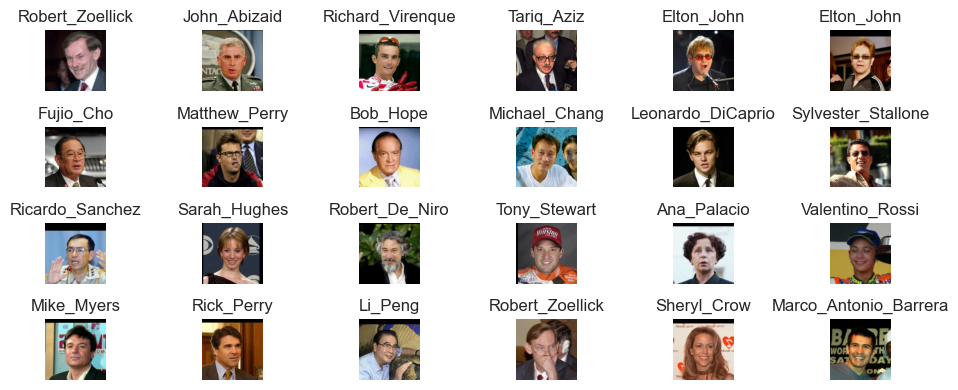

In [5]:
from math import ceil

SEED = 17
set_random_seed(SEED)

NUM_SAMPLES = 24
N_COLS = 6

classes = train_ds.classes
indices = torch.randperm(len(train_ds))[:NUM_SAMPLES]
images = [train_ds[i] for i in indices]

fig, ax = plt.subplots(ceil(NUM_SAMPLES/N_COLS), N_COLS, figsize=(10, 4))
for i in range(NUM_SAMPLES):
    img = images[i][0]
    axis = ax[i // N_COLS, i % N_COLS]
    axis.imshow(img.permute(1, 2, 0))
    axis.axis('off')
    axis.title.set_text(classes[images[i][1]])

plt.tight_layout()
plt.show()

Наконец, следует вывести распределение фотографий по людям и убедиться, что для каждого человека действительно предствалено 6-9 фотографий.

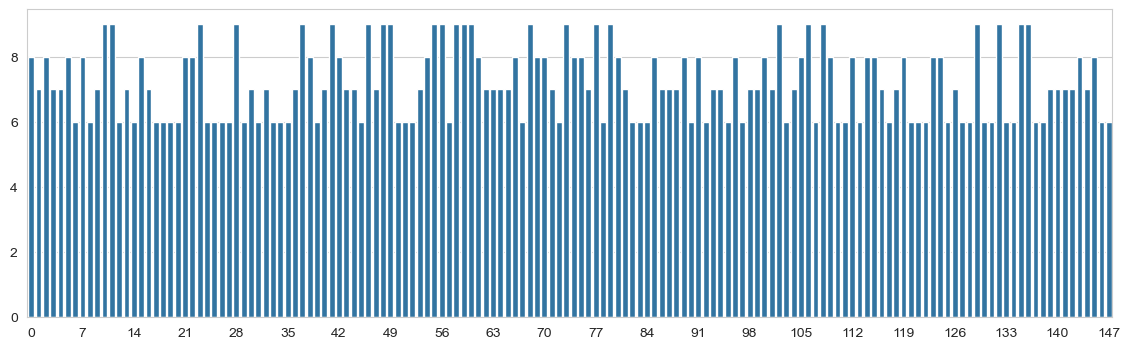

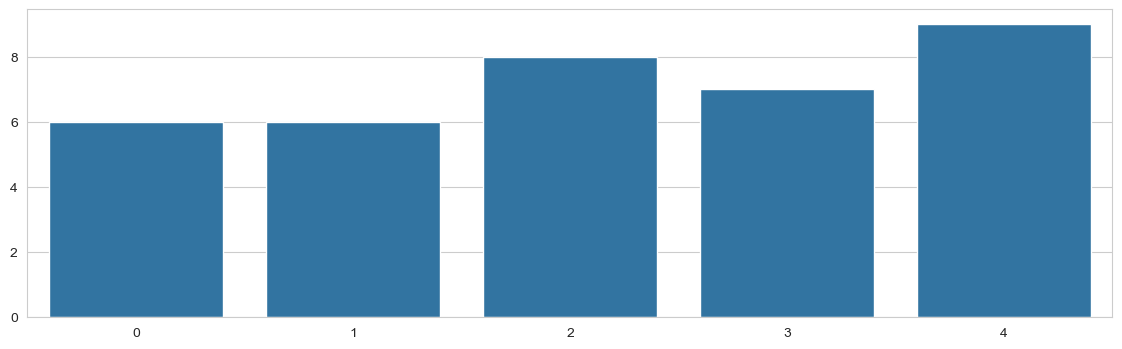

In [6]:
import seaborn as sns

def show_class_distribtion(targets):
    plt.figure(figsize=(14, 4))
    max_targ = np.max(targets)
    x = range(max_targ + 1)
    sns.barplot(x=x, y=[targets.count(i) for i in x])
    step = 1 if max_targ < 20 else max_targ // 20
    plt.xticks(range(0, max_targ + 1, step))
    plt.show()

show_class_distribtion(train_ds.targets)
show_class_distribtion(test_ds.targets)

##### [0 баллов] Задание 1.2. Датасет пар.

Как было сказано ранее, мы будем обучать модели предсказывать, разные ли люди изображены на фотографиях. Для этого нам надо научиться формировать пары фотографий и целевую переменную из двух классов: 0 и 1. \
Класс 0 означает, что это фотографии одного человека. \
Класс 1 означает фотографии разных людей. \
 \
К счастью, весь датасет уже написан.

In [53]:
class PairDataset(torch.utils.data.Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
        self.targets = [ self._get_target(i) for i in tqdm.trange(len(self)) ]

    def _idx1(self, idx):
        return idx % len(self.dataset)
    
    def _idx2(self, idx):
        return idx // len(self.dataset)
    
    def _get_target(self, idx):
        return int(self.dataset.targets[self._idx1(idx)] != self.dataset.targets[self._idx2(idx)])

    def __len__(self):
        return len(self.dataset) ** 2

    def __getitem__(self, idx):
        image1, label1 = self.dataset[self._idx1(idx)]
        image2, label2 = self.dataset[self._idx2(idx)]
        return torch.tensor(image1, device=device), torch.tensor(image2, device=device), int(label1 != label2)
    
train_pairs = PairDataset(train_ds)
test_pairs = PairDataset(test_ds)

100%|██████████| 1296/1296 [00:00<00:00, 3446935.94it/s]


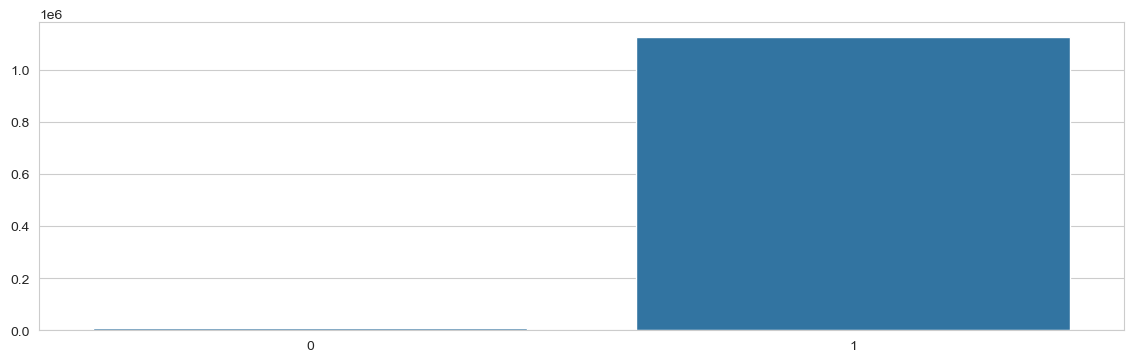

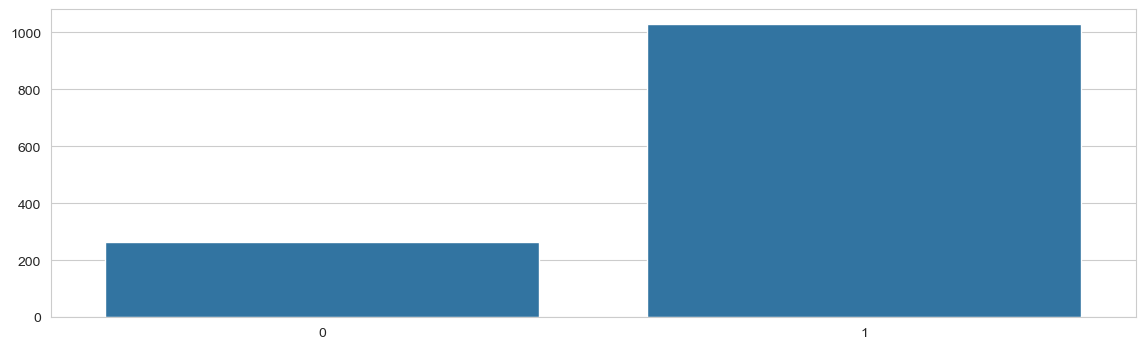

In [32]:
show_class_distribtion(train_pairs.targets)
show_class_distribtion(test_pairs.targets)

Легко видеть, что пар фотографий разных людей гораздо больше, чем пар фотографий одного человека. Это вполне ожидаемо, но, если не предпринять мер, ведет к двум проблемам:
1. Метрика качества предсказаний должна учитывать дисбаланс классов. В частности, accuracy нам не подойдёт. А использовать будем известный из курса машинного обучения AUC-ROC.
2. Нужно "подтюнить" даталоадер тренировочных данных, чтобы в каждый батч попадало примерно одинаковое количество фотографий каждого класса. Иначе победить деградацию модели к "всегда 1" будет очень сложно.

##### [1 балл] Задание 1.3. Стратифицированный даталоадер.

Для начала решим вторую проблему. Нужно сделать такой даталоадер, чтобы в каждом батче количество элементов класса "0" совпадало с количеством элементов класса "1".

Как известно, стандартный класс `DataLoader` в torch имеет много параметров. В частности, параметр `sampler` позволяет гибко управлять выдачей. Изучите [документацию](https://docs.pytorch.org/docs/stable/data.html#data-loading-order-and-sampler) и реализуйте свой семплер, который решит проблему.

В `pytorch_metric_learning` уже есть готовая реализация того, что нам нужно. Вы можете её найти и использовать. Но в таком случае __максимальный балл за это задание - 0.4__.

In [98]:
def where(array, value):
    if not isinstance(array, torch.Tensor) and not isinstance(array, np.ndarray):
        array = np.array(array)
    return np.atleast_1d(array == value).nonzero()[0]

In [192]:
class BalancedBatchSampler(torch.utils.data.Sampler):
    def __init__(self, labels):
        self.indices_class_0 = where(labels, 0)
        self.indices_class_1 = where(labels, 1)

        self.sample_count = min(len(self.indices_class_0), len(self.indices_class_1))

        super(BalancedBatchSampler, self).__init__()

    def __iter__(self):
        random.shuffle(self.indices_class_0)
        random.shuffle(self.indices_class_1)

        samples_0 = self.indices_class_0[:self.sample_count]
        samples_1 = self.indices_class_1[:self.sample_count]

        result = []
        for i in range(self.sample_count):
            result += [samples_0[i], samples_1[i]]

        return iter(result)

    def __len__(self):
        return self.sample_count * 2

/var/folders/7c/tj2klhqj0xj4m6bh_9hd8_g00000gn/T/ipykernel_1229/1925834642.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(image1, device=device), torch.tensor(image2, device=device), int(label1 != label2)


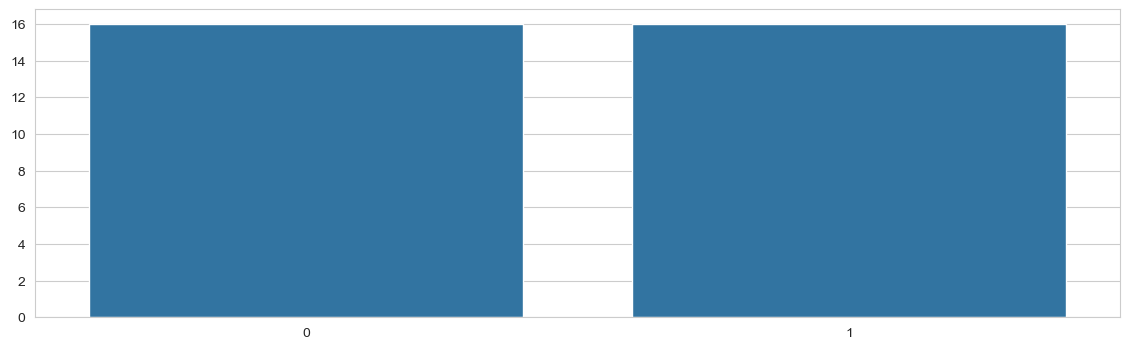

In [194]:
set_random_seed(SEED)

train_pairs_sampler = BalancedBatchSampler(train_pairs.targets)
train_pairs_loader = torch.utils.data.DataLoader(train_pairs, batch_size = 32, sampler = train_pairs_sampler)
test_pairs_loader = torch.utils.data.DataLoader(test_pairs, batch_size = 64, shuffle = False)

# Убедимся, что теперь выдача равномерная.
show_class_distribtion(next(iter(train_pairs_loader))[2].tolist())

### [3.5 балла] Часть 2. Классификация.

Начнём с простого: попробуем решить проблему как обычную задачу бинарной классификации. Реализуйте и обучите обычную свёрточную сеть, которая принимает два набора фотографий и предсказывает вероятность, что это фотографии разных людей.

##### [1 балл] Задание 2.1. Модель классификации.

Сначала нужно реализовать модель. В `forward` необходимо принять два батча фотографий. `i`-e число в выводе `forward` должно быть предсказанием для пары из `i`-й фотографии `image1` и `i`-й фотографии `image2`. Подумайте, как это сделать. Возможно, стоит как-нибудь склеить `image1` и `image2`? Или склеить эмбеддинги? А может быть нужен какой-то трешхолд?

Вы вольны использовать любую архитектуру сети. Ассерт в конце ячейки поможет вам убедиться, что модель теоретически делает то, что нужно.

In [204]:
import torch.nn as nn

class ClassificationNet(torch.nn.Module):
    def __init__(self):
        super(ClassificationNet, self).__init__()

        self.backbone = nn.Sequential(
                    # 3x250x250 -> 32x125x125
                    nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
                    nn.BatchNorm2d(32),
                    nn.LeakyReLU(),
                    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
                    nn.BatchNorm2d(32),
                    nn.LeakyReLU(),
                    nn.MaxPool2d(kernel_size=2, stride=2),

                    # 32x125x125 -> 64x62x62
                    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
                    nn.BatchNorm2d(64),
                    nn.LeakyReLU(),
                    nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
                    nn.BatchNorm2d(64),
                    nn.LeakyReLU(),
                    nn.MaxPool2d(kernel_size=2, stride=2),

                    # 64x62x62 -> 128x31x31
                    nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
                    nn.BatchNorm2d(128),
                    nn.LeakyReLU(),
                    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
                    nn.BatchNorm2d(128),
                    nn.LeakyReLU(),
                    nn.MaxPool2d(kernel_size=2, stride=2),

                    # 128x31x31 -> 256x15x15
                    nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
                    nn.BatchNorm2d(256),
                    nn.LeakyReLU(),
                    nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
                    nn.BatchNorm2d(256),
                    nn.LeakyReLU(),
                    nn.MaxPool2d(kernel_size=2, stride=2),

                    nn.AdaptiveAvgPool2d((1, 1))
                )

        self.head = nn.Sequential(
            nn.Linear(in_features=512, out_features=1000),
            nn.BatchNorm1d(1000),
            nn.LeakyReLU(),
            nn.Linear(in_features=1000, out_features=1),
            nn.Sigmoid()
        )

    def forward(self, image1, image2):
        batch_size = image1.shape[0]

        features_1 = self.backbone(image1).view(batch_size, -1)
        features_2 = self.backbone(image2).view(batch_size, -1)

        features = torch.cat((features_1, features_2), dim=1)
        scores = self.head(features)
        return scores.squeeze()

# Вы можете использовать этот ассерт в качестве теста, что ваша модель делает то, что нужно.
model = ClassificationNet().to(device)
assert model(*next(iter(train_pairs_loader))[:2]).shape == (32,)

/var/folders/7c/tj2klhqj0xj4m6bh_9hd8_g00000gn/T/ipykernel_1229/1925834642.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(image1, device=device), torch.tensor(image2, device=device), int(label1 != label2)


##### [2 балла] Задание 2.2. Обучение.

Теперь обучите свою модель и добейтесь приемлемого качества. Балл за это задание вычисляется по формуле:

$$ clamp(0, 2.5 \cdot \dfrac{AucRoc - 0.6}{0.2}, 2.5) $$

То есть, для получения полного балла за это задание необходимо добиться AUC-ROC `0.8`

__При использовани предобученных моделей, балл за это задание умножается на 0.5__ (то есть, не более 1)

In [197]:
from tqdm.auto import tqdm
from IPython.display import clear_output

def plot_losses(train_losses, test_losses, train_accuracies, test_accuracies):
    clear_output()
    fig, axs = plt.subplots(1, 2, figsize=(13, 4))
    axs[0].plot(range(1, len(train_losses) + 1), train_losses, label='train')
    axs[0].plot(range(1, len(test_losses) + 1), test_losses, label='test')
    axs[0].set_ylabel('loss')

    axs[1].plot(range(1, len(train_accuracies) + 1), train_accuracies, label='train')
    axs[1].plot(range(1, len(test_accuracies) + 1), test_accuracies, label='test')
    axs[1].set_ylabel('accuracy')

    for ax in axs:
        ax.set_xlabel('epoch')
        ax.legend()

    plt.show()

def training_epoch(model, optimizer, criterion, train_loader, tqdm_desc):
    """Одна эпоха обучения"""
    train_loss, train_accuracy = 0.0, 0.0
    model.train()
    for image1, image2, labels in tqdm(train_loader, desc=tqdm_desc):
        image1, image2, labels = image1.to(device), image2.to(device), labels.float().to(device)

        optimizer.zero_grad()
        logits = model(image1, image2)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * image1.shape[0]
        preds = (torch.sigmoid(logits) > 0.5).long()
        train_accuracy += (preds == labels.long()).sum().item()

    train_loss /= len(train_loader.sampler)
    train_accuracy /= len(train_loader.sampler)
    return train_loss, train_accuracy


@torch.no_grad()
def validation_epoch(model, criterion, val_loader, tqdm_desc):
    """Прогнозы на валидации"""

    val_loss, val_accuracy = 0.0, 0.0
    model.eval()
    for image1, image2, labels in tqdm(val_loader, desc=tqdm_desc):
        image1, image2, labels = image1.to(device), image2.to(device), labels.float().to(device)

        logits = model(image1, image2)
        loss = criterion(logits, labels)

        val_loss += loss.item() * image1.shape[0]
        preds = (torch.sigmoid(logits) > 0.5).long()
        val_accuracy += (preds == labels.long()).sum().item()

    val_loss /= len(val_loader.dataset)
    val_accuracy /= len(val_loader.dataset)
    return val_loss, val_accuracy


def train(model, optimizer, criterion, train_loader, val_loader, num_epochs, scheduler=None, model_save_path='best_model.pt2'):
    """Обучение модели"""
    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []

    best_val_accuracy = 0.0

    for epoch in range(1, num_epochs + 1):
        train_loss, train_accuracy = training_epoch(
            model, optimizer, criterion, train_loader,
            tqdm_desc=f'Training {epoch}/{num_epochs}',
        )
        val_loss, val_accuracy = validation_epoch(
            model, criterion, val_loader,
            tqdm_desc=f'Validating {epoch}/{num_epochs}'
        )

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        if scheduler is not None:
            scheduler.step()

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            torch.save(model.state_dict(), model_save_path)

        plot_losses(train_losses, val_losses, train_accuracies, val_accuracies)

    print(f"Epoch: {epoch}, loss: {np.mean(val_loss)}, accuracy: {np.mean(val_accuracy)}")

In [ ]:
set_random_seed(SEED)

model = ClassificationNet().to(device)

loss = nn.BCELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

train(model, optimizer, loss, train_pairs_loader, test_pairs_loader, 10)

In [206]:
def get_score(auc_roc):
    return max(0, min(2.5 * (auc_roc - 0.6) / 0.2, 2.5))

def get_auc_roc(your_model):
    preds = []
    targets = []
    your_model.eval()
    for images1, images2, labels in tqdm(test_pairs_loader):
        with torch.no_grad():
            output = your_model(images1.to(device), images2.to(device))
        preds.extend(output.detach().cpu().tolist())
        targets.extend(labels.detach().cpu().tolist())
    preds = np.array(preds)
    targets = np.array(targets)
    return sklearn.metrics.roc_auc_score(targets, preds)

auc_roc = get_auc_roc(model)
print(auc_roc)
get_score(auc_roc)

  0%|          | 0/21 [00:00<?, ?it/s]

/var/folders/7c/tj2klhqj0xj4m6bh_9hd8_g00000gn/T/ipykernel_1229/1925834642.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(image1, device=device), torch.tensor(image2, device=device), int(label1 != label2)


0.9074713482735965


2.5

##### [0.5 балла] Задание 2.3. Анализ и отчет.

Опишите свои эксперименты. Проанализируйте результаты. Почему результаты получились не очень хорошими? Может быть, решать задачу через бинарную классификацию - не лучшая идея? Приведите не менее 3 аргументов, почему это так.

**Ответ:** во-первых, я этот результат два часа выбивал без учета обучения, в смысле не очень хорошими(((( AUC-ROC в 0.9 вполне себе ничего.

В ходе экспериментов я успел поправить неправильно написанный лоадер и механизм склейки эмбеддингов. Когда всё начало работать, но плохо, я в основном занимался увеличением модели - изначально я пытался обойтись двумя блоками в бэкбоне и сильно меньшим количеством скрытых слоёв в голове, в итоге дважды их пришлось увеличить.

Почему здесь бинарная классификация это плохо:
1. Изначально вся эта идея со склейкой эмбеддингов кажется странной - было бы логичнее, быть может, искать между ними расстояние? В общем, как будто есть способы логичнее. (ахахахх, я правда это написал до того, как прочитал следующую часть).
2. Если мы захотим добавить нового человека, нам придётся переобучать ВСЮ модель.
3. Порядок подачи картинок в нашем случае может вполне себе серьезно влиять на результат. В целом наш способ какой-то очень эвристический и полагается на то, что мы модели на вход подадим кашу из признаков, а она там сама как-то с ней будет работать, это антиматематически и антинаучно.

### [5 баллов] Часть 3. Распознавание лиц.

Теперь попробуем использовать более хитрые методы, которые лучше подходят для решаемой задачи. В частности, триплетную функцию потерь. Далее наша модель будет не предсказывать вероятность для двух картинок, а формировать эмбеддинги для одной картинки таким образом, чтобы эмбеддинги фотографий одного человека были близки, а разных людей - далеки.

##### [2 балла] Задание 3.1. Триплетная функция потерь.

Напомним теорию. Пусть $A$ - произвольное изображение; $P$ - изображение того же человека (позитивный пример); $N$ - изображение любого другого человека (негативный пример); $f$ - наша нейронная сеть; $\alpha$ - гиперпараметр, отвечающий за желаемый “отступ” – расстояние между латентными представлениями изображений разных людей. Тогда функционал ошибки определяется следующим образом:

$$ L(A, P, N) = max(||f(A) - f(P)|| - ||f(A) - f(N)|| + \alpha, 0) $$

В этом задании вам необходимо реализовать этот функционал. Для удобства в дальнейшем, предлагается сразу реализовать batch-версию. Таким образом, на входе должно быть 2 параметра:
- Набор эмбеддингов размера (batch_size, embedding_size)
- Набор классов (номера людей, чьи это фотографии) размера (batch_size)

Ваша функция должна найти все тройки $(A, P, N)$ и вычислить лосс для них.

В `pytorch_metric_learning` уже есть готовая реализация. Вы можете её найти и использовать. Но в таком случае __максимальный балл за это задание - 0.5__.

In [ ]:
criterion = ### YOUR CODE HERE ###(margin = 0.25)

In [120]:
# Вы можете использовать этот ассерт в качестве теста
embeddings = torch.tensor([
    [ 1., 2, 3 ],
    [ 1, 3, 4 ],
    [ 4, 5, 6 ]
])
labels = torch.tensor([ 1., 2, 1 ])
assert (criterion(embeddings, labels) - 2.6775) < 1e-4

##### [3 балла] Задание 3.2. Обучение.

Теперь обучите модель и добейтесь приемлемого качества. Балл за это задание вычисляется по формуле:

$$ clamp(0, 3 \cdot \dfrac{AucRoc - 0.8}{0.15}, 3) $$

То есть, для получения полного балла за это задание необходимо добиться AUC-ROC `0.95`

При необходимости, вы можете улучшить функцию потерь. Например, учитывать не все тройки, а только "сложные", как это умеет делать реализация в `pytorch_metric_learning`. Также подумайте над даталоадером. Возможно, имеет смысл брать в батч одинаковое количество фотографий каждого человека по аналгии с заданием 1.3? Тем не менее имейте в виду, что для получения полного балла за задание, вы должны реализовать все модификации самостоятельно, а не использовать готовые.

__При использовани предобученных моделей, балл за это задание умножается на 0.5__ (то есть, не более 1.5) \
__При использовани pytorch_metric_learning, балл за это задание уменьшается на 0.5 за каждое использование__

In [ ]:
### YOUR CODE HERE ###

In [ ]:
def get_score(auc_roc):
    return max(0, min(3 * (auc_roc - 0.8) / 0.15, 3))

def get_auc_roc(your_model):
    preds = []
    targets = []
    your_model.eval()
    for images1, images2, labels in tqdm.tqdm(test_pairs_loader):
        with torch.no_grad():
            emb1 = your_model(images1.to(device))
            emb2 = your_model(images2.to(device))
            # Вы можете изменить функцию расстояния между эмбеддингами, если считаете нужным
            dist = ((emb1 - emb2) ** 2).sum(dim = 1)
        preds.extend(dist.detach().cpu().tolist())
        targets.extend(labels.detach().cpu().tolist())
    preds = numpy.array(preds)
    targets = numpy.array(targets)
    return sklearn.metrics.roc_auc_score(targets, preds)

get_score(get_auc_roc(model))

##### [0.1 балла] Бонус: распознай себя

В качестве бонуса, загрузите свою фотографию (можно не одну), пропустите ее через модель и определите, на кого из известных людей, по мнению модели, вы больше всего похоже.

In [ ]:
### YOUR CODE HERE ###